# 📱 Customer Churn Prediction using Machine Learning

# Proyect Overview

Customer churn is one of the most important challenges faced by subscription-based businesses. Acquiring new customers is often more expensive than retaining existing ones, making churn prediction a valuable business application.

In this project, a machine learning model is developed to predict whether a telecommunications customer is likely to leave the company based on their account information, service usage, and interaction history.

The project follows a complete machine learning workflow, including data exploration, preprocessing, feature engineering, model development, evaluation, and business interpretation.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook

# 🎯 Business Problem

Customer retention is a critical objective for telecommunications companies. Losing customers not only reduces revenue but also increases acquisition costs associated with replacing them.

The objective of this project is to develop a predictive model capable of identifying customers who are at high risk of churning before they leave the company.

Such predictions enable the business to proactively implement retention strategies, optimize marketing efforts, and improve customer satisfaction.

# Import Libraries

In [28]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Load Dataset

In [3]:
df = pd.read_csv("data/telecom_churn.csv")

# Exploratory Data Analysis

In [4]:
# Display the first five rows
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [5]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 3333
Columns: 11


In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


Dataset Overview

The dataset contains **3,333 customer records** and **11 features**.

Based on the output of `df.info()`, every feature contains **3,333 non-null values**, indicating that there are **no missing values** in the dataset. This simplifies the preprocessing stage, as no imputation techniques will be required before model development.

In [7]:
# Summary statistics
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


# Target Variable Analysis

In [8]:
# Class distribution
df["Churn"].value_counts()

,count
Churn,
0,2850
1,483


In [10]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

,proportion
Churn,
0,85.51
1,14.49


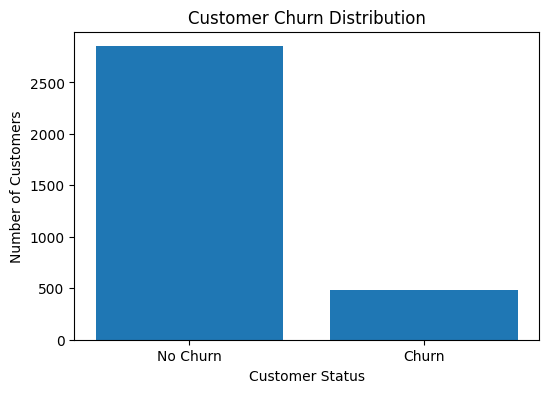

In [84]:
# Class distribution
churn_counts = df["Churn"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["No Churn", "Churn"], churn_counts)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.savefig("churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Conclusion

The target variable is moderately imbalanced. Approximately **85.5%** of customers remained with the company, while only **14.5%** churned.

This indicates that customer churn is a relatively infrequent event. Consequently, relying solely on accuracy to evaluate model performance may be misleading. Additional evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be considered during model assessment.

# Numerical Feature Analysis

In [12]:
# Numerical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

numerical_features

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='object')

In [13]:
numerical_features = numerical_features.drop("Churn")

## Account Weeks

This feature represents the number of weeks a customer has been with the company. Analyzing its distribution helps determine whether customer tenure varies significantly across the dataset and whether unusually low or high values exist.

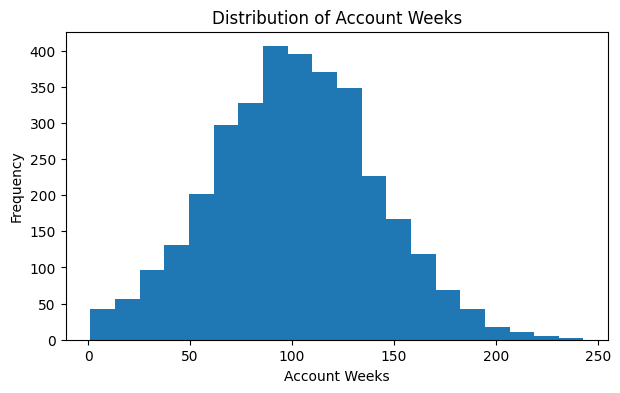

In [14]:
plt.figure(figsize=(7,4))

plt.hist(df["AccountWeeks"], bins=20)

plt.title("Distribution of Account Weeks")
plt.xlabel("Account Weeks")
plt.ylabel("Frequency")

plt.show()

### Conclusion

The distribution of **AccountWeeks** appears to be relatively uniform across the observed range, indicating that customers have varying lengths of service with the company.

No significant gaps or unusual patterns are observed, suggesting that the feature provides a broad representation of customer tenure. While no obvious anomalies are visible from the distribution alone, further analysis will determine whether the length of time a customer has been with the company is associated with churn.

## Contract Renewal

This feature indicates whether a customer has renewed their contract with the company. Examining its distribution provides insight into how common contract renewals are within the customer base before analyzing their potential relationship with customer churn.

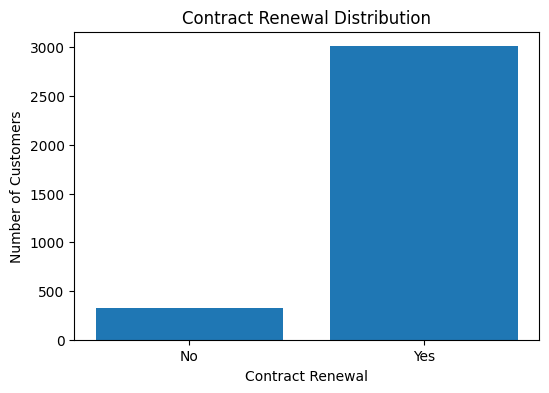

In [16]:
contract_counts = df["ContractRenewal"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(["No", "Yes"], contract_counts)

plt.title("Contract Renewal Distribution")
plt.xlabel("Contract Renewal")
plt.ylabel("Number of Customers")

plt.show()

### Conclusion

Most customers have renewed their contract, while only a small proportion have not. This indicates that contract renewal is common among the customer base.

Although the distribution is moderately imbalanced, it does not provide enough information to determine whether contract renewal influences customer churn. Its relationship with the target variable will be examined in a later section.

## Data Plan

This feature indicates whether a customer subscribes to a data plan. Analyzing its distribution provides insight into the adoption of data services among customers before evaluating its potential relationship with customer churn.

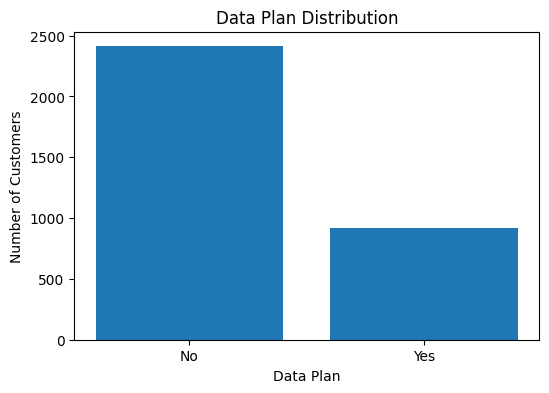

In [18]:
plan_counts = df["DataPlan"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(["No", "Yes"], plan_counts)

plt.title("Data Plan Distribution")
plt.xlabel("Data Plan")
plt.ylabel("Number of Customers")

plt.show()

### Conclusion

Most customers do not subscribe to a data plan, while a considerable proportion do. Although customers without a data plan represent the majority, the distribution is not highly imbalanced.

Based on this distribution alone, it is not possible to determine whether subscribing to a data plan affects customer churn. The relationship between this feature and the target variable will be explored in a later stage of the analysis.

## Customer Service Calls

This feature represents the number of customer service calls made by each customer. Analyzing its distribution helps identify how frequently customers contact support and whether unusual calling patterns exist within the dataset.

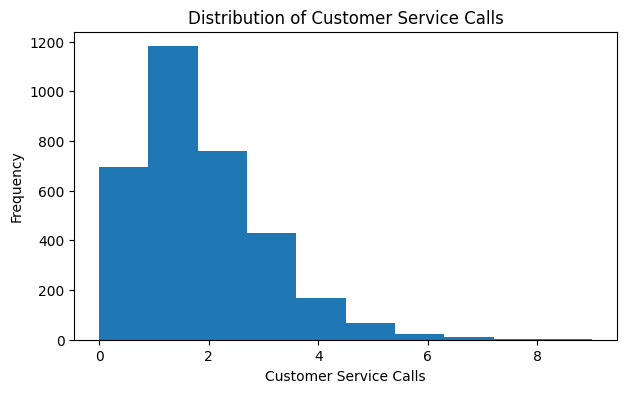

In [19]:
plt.figure(figsize=(7,4))

plt.hist(df["CustServCalls"], bins=10)

plt.title("Distribution of Customer Service Calls")
plt.xlabel("Customer Service Calls")
plt.ylabel("Frequency")

plt.show()

### Conclusion

The distribution of **Customer Service Calls** is positively skewed, with most customers making only a small number of calls to customer service. The frequency decreases rapidly as the number of calls increases, indicating that customers requiring frequent support are relatively uncommon.

This pattern suggests that a high number of customer service calls may represent unusual customer behavior. Whether frequent interactions with customer support are associated with customer churn will be investigated in a later stage of the analysis.

## Day Minutes

This feature represents the total number of daytime call minutes used by each customer. Examining its distribution helps understand typical daytime usage patterns and identify any unusual consumption behavior within the dataset.

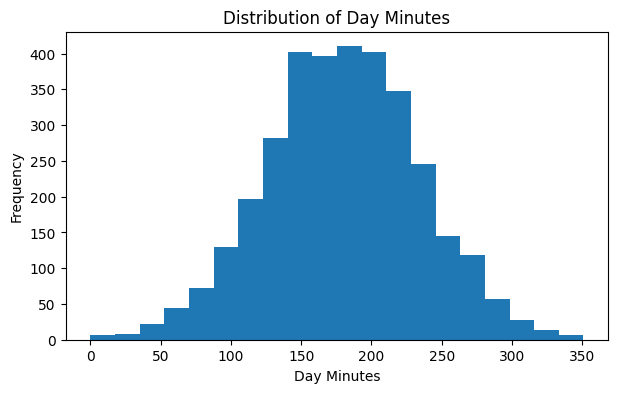

In [20]:
plt.figure(figsize=(7,4))

plt.hist(df["DayMins"], bins=20)

plt.title("Distribution of Day Minutes")
plt.xlabel("Day Minutes")
plt.ylabel("Frequency")

plt.show()

### Conclusion

The distribution of **Day Minutes** is approximately normal, with most customers accumulating a moderate number of daytime call minutes. No strong skewness or unusual patterns are evident from the histogram.

This suggests that daytime call usage is relatively consistent across the customer base. Further analysis will determine whether differences in daytime usage are associated with customer churn.

## Day Calls

This feature represents the total number of daytime calls made by each customer. Examining its distribution helps identify typical calling behavior and assess the variability in daytime call frequency across the customer base.

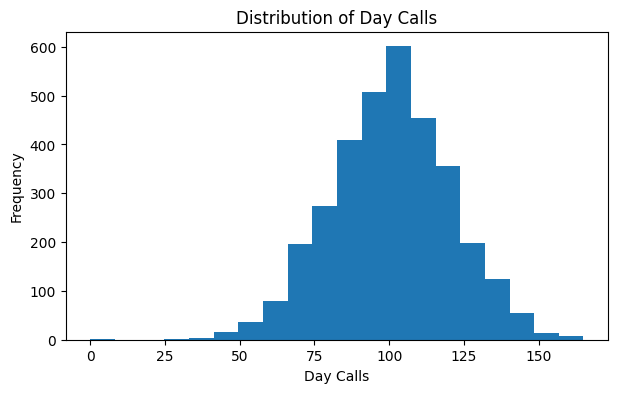

In [21]:
plt.figure(figsize=(7,4))

plt.hist(df["DayCalls"], bins=20)

plt.title("Distribution of Day Calls")
plt.xlabel("Day Calls")
plt.ylabel("Frequency")

plt.show()

### Conclusion

The distribution of **Day Calls** is approximately bell-shaped, with most customers making between 30 and 175 daytime calls and a peak around 100 calls.

A small number of customers exhibit unusually low call counts, which may represent potential outliers. Aside from these isolated observations, the feature shows a relatively consistent distribution across the customer base.

Further analysis will determine whether daytime calling frequency is associated with customer churn.

## Monthly Charge

This feature represents the monthly amount charged to each customer for the services provided. Analyzing its distribution helps understand the pricing structure across the customer base and identify any unusual billing patterns.

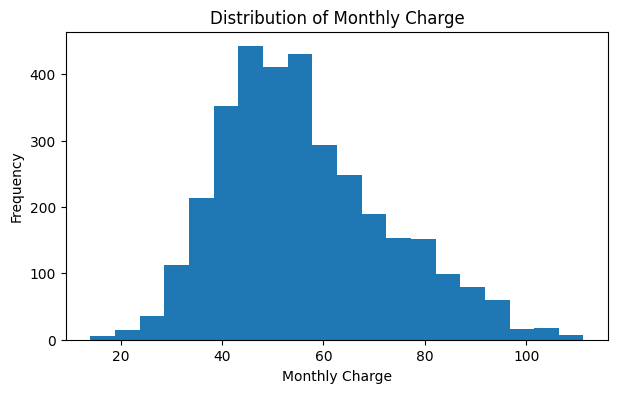

In [24]:
plt.figure(figsize=(7,4))

plt.hist(df["MonthlyCharge"], bins=20)

plt.title("Distribution of Monthly Charge")
plt.xlabel("Monthly Charge")
plt.ylabel("Frequency")

plt.show()

### Conclusion

The distribution of **Monthly Charge** exhibits a slight positive skew, with most customers concentrated around moderate monthly charges. Two noticeable concentration areas are observed, suggesting that customers tend to fall into different pricing ranges.

No extreme values or unusual patterns are immediately apparent. Further analysis will determine whether customers with higher monthly charges are more likely to churn.

## Overage Fee

This feature represents the additional charges incurred by customers when they exceed their service limits. Examining its distribution helps identify how common overage fees are and whether customers tend to accumulate similar or widely varying additional charges.

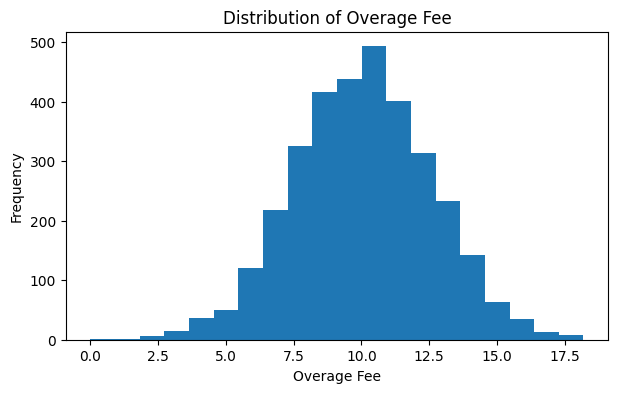

In [25]:
plt.figure(figsize=(7,4))

plt.hist(df["OverageFee"], bins=20)

plt.title("Distribution of Overage Fee")
plt.xlabel("Overage Fee")
plt.ylabel("Frequency")

plt.show()

### Conclusion

The distribution of **Overage Fee** is concentrated between approximately 2.5 and 17.5, with most customers incurring moderate additional charges. A small number of customers exhibit unusually low overage fees, which may represent isolated observations.

Overall, the feature displays a consistent distribution without pronounced irregularities. Further analysis will determine whether customers with higher overage fees are more likely to churn.

## Roaming Minutes

This feature represents the total number of roaming minutes used by each customer. Examining its distribution helps understand roaming usage patterns and identify whether customers exhibit similar or highly variable international calling behavior.

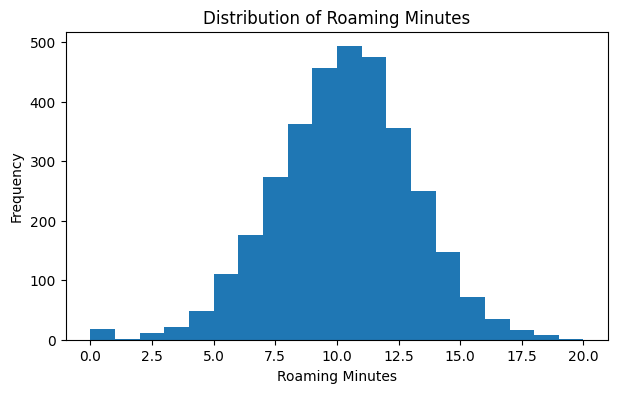

In [27]:
plt.figure(figsize=(7,4))

plt.hist(df["RoamMins"], bins=20)

plt.title("Distribution of Roaming Minutes")
plt.xlabel("Roaming Minutes")
plt.ylabel("Frequency")

plt.show()

### Conclusion

The distribution of **Roaming Minutes** is concentrated between approximately 2.5 and 18.5 minutes, with most customers using a moderate amount of roaming services. A small number of customers exhibit unusually low roaming usage, which may represent isolated observations or potential outliers.

Overall, the feature shows a relatively consistent distribution across the customer base. Whether roaming usage influences customer churn will be explored in a later stage of the analysis.

### Overall Findings

Most numerical features exhibit well-behaved distributions without severe skewness or large numbers of outliers. Several variables, such as **Day Calls**, **Overage Fee**, and **Roaming Minutes**, contain a small number of isolated low-value observations, while others, including **Monthly Charge**, show slight variations in customer concentration across different value ranges.

These observations provide a solid understanding of the dataset and establish a foundation for investigating relationships between customer characteristics and churn in the following sections.

# Correlation Analysis

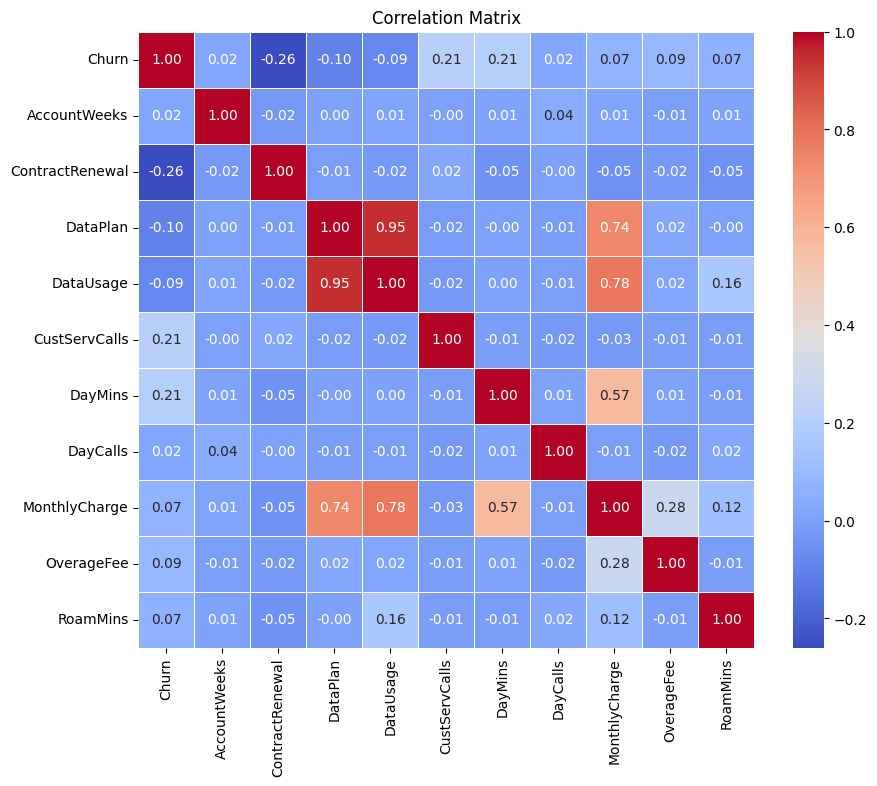

In [86]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

corr_pairs = (
    corr.mask(mask)
        .stack()
        .sort_values(key=abs, ascending=False)
)

corr_pairs.head(10)

DataUsage        DataPlan         0.945982
MonthlyCharge    DataUsage        0.781660
                 DataPlan         0.737490
                 DayMins          0.567968
OverageFee       MonthlyCharge    0.281766
ContractRenewal  Churn           -0.259852
CustServCalls    Churn            0.208750
DayMins          Churn            0.205151
RoamMins         DataUsage        0.162746
                 MonthlyCharge    0.117433
dtype: float64

### Conclusion

The correlation analysis reveals that most numerical features exhibit weak to moderate linear relationships, suggesting limited multicollinearity across the dataset.

The strongest positive correlation is observed between **Data Usage** and **Data Plan** (0.95), indicating that customers subscribed to a data plan tend to consume substantially more data. **Monthly Charge** also shows strong positive correlations with **Data Usage** (0.78) and **Data Plan** (0.74), reflecting the expected relationship between service usage and monthly billing.

Regarding the target variable, **Contract Renewal** presents the strongest negative correlation with **Churn** (-0.26), while **Customer Service Calls** (0.21) and **Day Minutes** (0.21) exhibit the strongest positive correlations. Although these relationships are moderate, they suggest that contract renewal status, customer support interactions, and daytime usage may be important predictors of customer churn and will be explored further in the next section.

# Relationship Between Features and Churn

This section examines how each feature differs between customers who churned and those who remained with the company. Identifying these relationships helps uncover potential drivers of customer attrition and provides valuable business insights before developing predictive models.

## Contract Renewal vs Churn

Contract renewal is expected to play an important role in customer retention. Comparing churn rates between customers who renewed their contracts and those who did not can provide insights into whether contract commitment is associated with customer loyalty.

/tmp/ipykernel_1765/3776948316.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


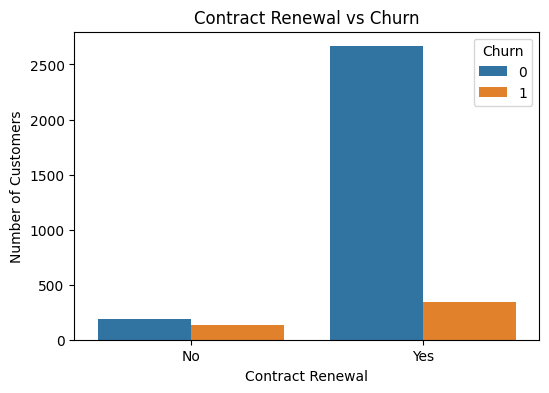

In [37]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="ContractRenewal",
    hue="Churn"
)

ax.set_xticklabels(["No", "Yes"])

plt.title("Contract Renewal vs Churn")
plt.xlabel("Contract Renewal")
plt.ylabel("Number of Customers")

plt.show()

### Conclusion

Customers who did not renew their contracts exhibit similar numbers of churned and retained customers, suggesting a relatively high churn rate within this group. In contrast, among customers who renewed their contracts, the vast majority remained with the company, while only a small proportion churned.

These findings indicate that **contract renewal is strongly associated with customer retention**, making it one of the most relevant factors for predicting customer churn. This observation is also consistent with the negative correlation between **Contract Renewal** and **Churn** identified in the previous section.

### Customer Service Calls vs Churn

Frequent interactions with customer support may indicate dissatisfaction or unresolved issues. Comparing the distribution of customer service calls between churned and retained customers can help determine whether support activity is associated with customer attrition.

/tmp/ipykernel_1765/2623860931.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


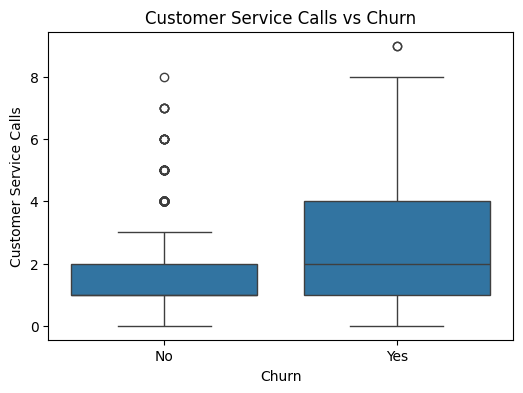

In [38]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="CustServCalls"
)
ax.set_xticklabels(["No", "Yes"])

plt.title("Customer Service Calls vs Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Service Calls")

plt.show()

### Conclusion

Customers who churned generally exhibit a higher number of customer service calls than those who remained with the company. The distribution for churned customers is shifted toward larger values and displays greater variability, indicating that these customers tend to contact customer support more frequently.

Although both groups contain some outliers with unusually high numbers of service calls, the overall pattern suggests that frequent interactions with customer support are associated with an increased likelihood of customer churn. This finding is consistent with the positive correlation observed between **Customer Service Calls** and **Churn** in the previous section.

### Day Minutes vs Churn

Daytime call usage represents one of the primary measures of customer activity. Comparing usage between churned and retained customers may reveal whether heavier daytime usage is associated with a greater likelihood of churn.

/tmp/ipykernel_1765/893652586.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


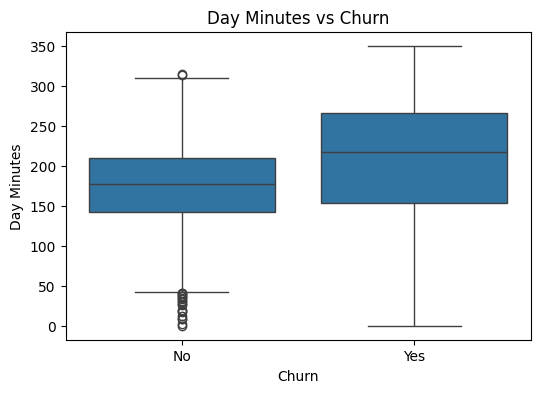

In [39]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="DayMins"
)

ax.set_xticklabels(["No", "Yes"])

plt.title("Day Minutes vs Churn")
plt.xlabel("Churn")
plt.ylabel("Day Minutes")

plt.show()

### Conclusion

Customers who churned generally accumulated more daytime call minutes than those who remained with the company. The distribution for churned customers is shifted toward higher values, with both the median and the interquartile range exceeding those of retained customers.

Although both groups contain some outliers, the overall pattern suggests that customers with heavier daytime call usage are more likely to churn. This observation is consistent with the positive correlation identified between **Day Minutes** and **Churn**, indicating that daytime calling behavior may be a useful predictor of customer attrition.

### Data Plan vs Churn

Subscribing to a data plan may influence customer retention by providing additional services and value. Comparing churn across customers with and without a data plan helps evaluate whether this feature is associated with customer loyalty.

/tmp/ipykernel_1765/398332007.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


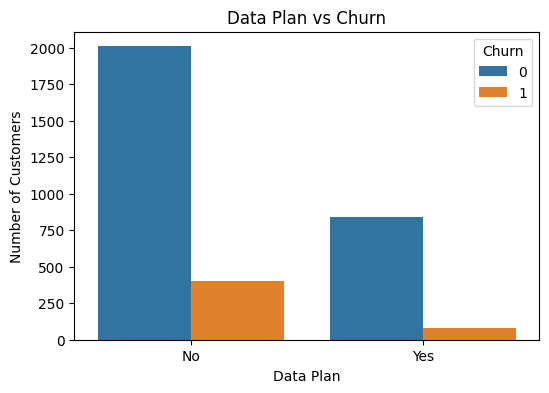

In [41]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="DataPlan",
    hue="Churn"
)
ax.set_xticklabels(["No", "Yes"])

plt.title("Data Plan vs Churn")
plt.xlabel("Data Plan")
plt.ylabel("Number of Customers")

plt.show()

### Conclusion

Most customers remained with the company regardless of whether they subscribed to a data plan. In both groups, retained customers substantially outnumber those who churned.

Customers with a data plan appear to exhibit a slightly lower proportion of churn compared with customers without a data plan, suggesting that subscribing to a data plan may be associated with improved customer retention. However, the difference is less pronounced than the relationship observed for **Contract Renewal**, indicating that **Data Plan** may be a weaker predictor of customer churn.

### Data Usage vs Churn

Customer data consumption reflects the level of engagement with mobile services. Comparing data usage between churned and retained customers may indicate whether heavier usage is associated with customer retention or attrition.

/tmp/ipykernel_1765/3036275825.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


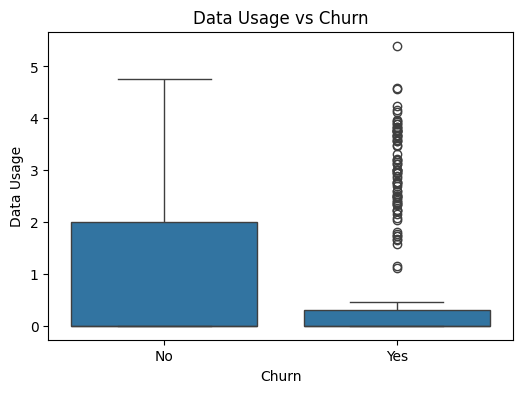

In [42]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="DataUsage"
)

ax.set_xticklabels(["No", "Yes"])
plt.title("Data Usage vs Churn")
plt.xlabel("Churn")
plt.ylabel("Data Usage")

plt.show()

### Conclusion

Most customers exhibit relatively low levels of data usage, resulting in highly concentrated distributions for both churn groups. The majority of observations are clustered near zero, while a number of customers with substantially higher data consumption appear as outliers.

Customers who churned tend to have lower typical data usage than retained customers, although a subset of churned customers displays relatively high data consumption. Overall, the distributions overlap considerably, suggesting that **Data Usage** alone may provide limited discrimination between churned and retained customers, despite its relationship with other variables such as **Data Plan** and **Monthly Charge**.

### Monthly Charge vs Churn

Monthly charges reflect the overall cost of the customer's subscribed services. Comparing monthly charges between churned and retained customers may reveal whether customers paying higher bills are more likely to discontinue the service.

/tmp/ipykernel_1765/2758946316.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


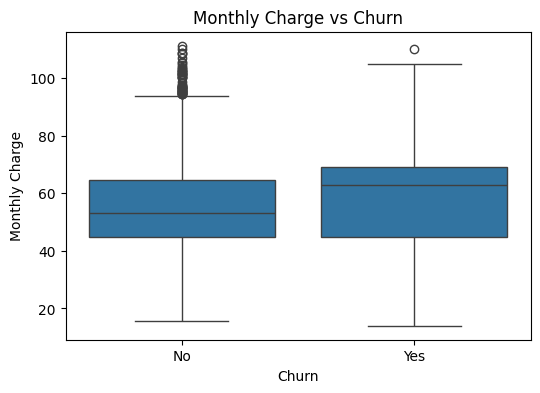

In [43]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharge"
)

ax.set_xticklabels(["No", "Yes"])

plt.title("Monthly Charge vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charge")

plt.show()

### Conclusion

Customers who churned tend to have slightly higher monthly charges than those who remained with the company. The median monthly charge and the overall spread of the distribution are both higher for churned customers, indicating that these customers generally pay more for their services.

Although the two distributions overlap considerably and both groups contain customers with unusually high monthly charges, the overall pattern suggests that higher monthly bills are associated with an increased likelihood of customer churn. This finding is also consistent with the positive correlation previously observed between **Monthly Charge** and **Churn**.

### Overage Fee vs Churn

Overage fees represent additional charges incurred when customers exceed their service limits. Comparing overage fees between churned and retained customers helps evaluate whether extra charges are associated with customer attrition.

/tmp/ipykernel_1765/2578845502.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


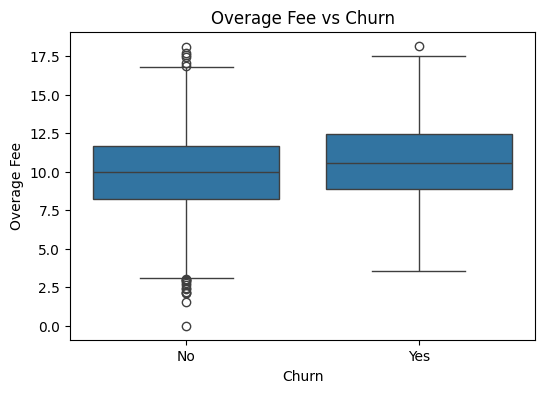

In [44]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="OverageFee"
)

ax.set_xticklabels(["No", "Yes"])

plt.title("Overage Fee vs Churn")
plt.xlabel("Churn")
plt.ylabel("Overage Fee")

plt.show()

### Conclusion

The distributions of **Overage Fee** are highly similar for customers who churned and those who remained with the company. Both groups exhibit comparable ranges, medians, and overall variability, although churned customers show a slightly higher median overage fee.

Several outliers are present in both groups, indicating that a small number of customers incur unusually low or high additional charges. Overall, the substantial overlap between the distributions suggests that **Overage Fee** alone is not a strong discriminator of customer churn, despite its slight positive relationship with the target variable observed in the correlation analysis.

### Roaming Minutes vs Churn

Roaming usage reflects customer activity outside their primary service area. Comparing roaming minutes between churned and retained customers may indicate whether roaming behavior is associated with customer churn.

/tmp/ipykernel_1765/3489014165.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


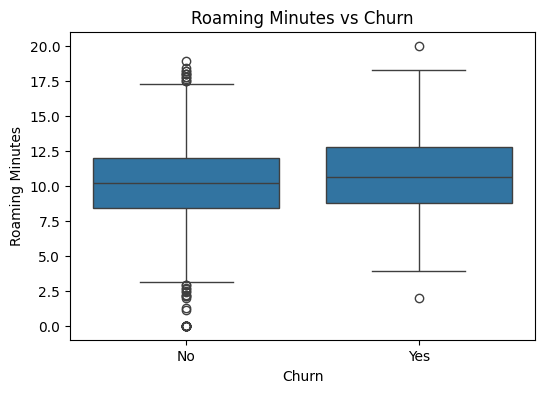

In [45]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="RoamMins"
)

ax.set_xticklabels(["No", "Yes"])

plt.title("Roaming Minutes vs Churn")
plt.xlabel("Churn")
plt.ylabel("Roaming Minutes")

plt.show()

### Conclusion

The distributions of **Roaming Minutes** are very similar for customers who churned and those who remained with the company. Both groups have comparable interquartile ranges, medians, and overall variability, with churned customers exhibiting only a slightly higher median roaming usage.

A small number of outliers are observed in both groups, representing customers with unusually low or high roaming activity. Overall, the substantial overlap between the distributions suggests that **Roaming Minutes** is not a strong standalone indicator of customer churn, although it may still provide useful information when combined with other predictive features.

### Account Weeks vs Churn

The number of weeks a customer has been with the company represents customer tenure. Comparing account age between churned and retained customers may reveal whether newer or long-term customers are more likely to leave the service.

/tmp/ipykernel_1765/894311138.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


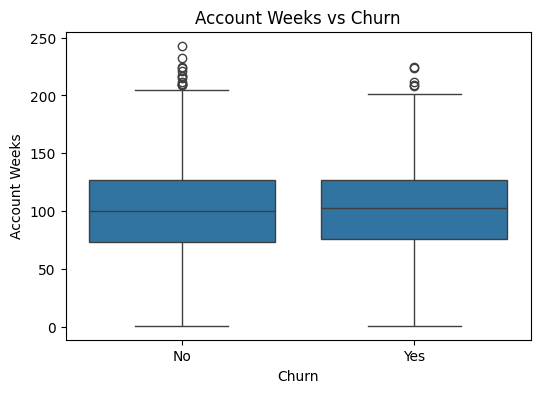

In [46]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="AccountWeeks"
)

ax.set_xticklabels(["No", "Yes"])

plt.title("Account Weeks vs Churn")
plt.xlabel("Churn")
plt.ylabel("Account Weeks")

plt.show()

### Conclusion

The distributions of **Account Weeks** are highly similar for customers who churned and those who remained with the company. Both groups exhibit comparable interquartile ranges, overall spread, and customer tenure, with churned customers showing only a slightly higher median account age.

Several customers in both groups have unusually long account durations, appearing as outliers above the upper whisker. Overall, the strong overlap between the distributions suggests that **Account Weeks** has limited ability to distinguish churned customers from retained customers when considered on its own.

### Day Calls vs Churn

The number of daytime calls measures how frequently customers use the service during the day. Comparing this feature between churned and retained customers helps determine whether calling frequency is associated with customer churn.

/tmp/ipykernel_1765/1947136923.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


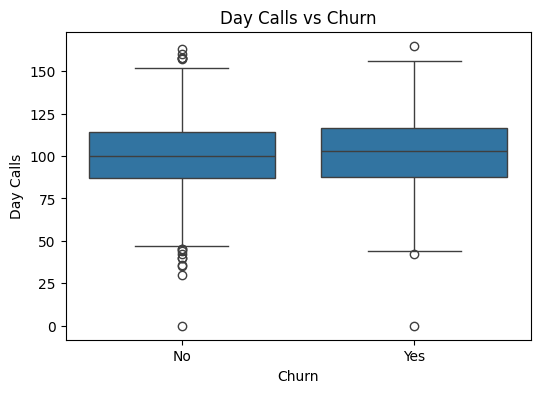

In [47]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="DayCalls"
)

ax.set_xticklabels(["No", "Yes"])

plt.title("Day Calls vs Churn")
plt.xlabel("Churn")
plt.ylabel("Day Calls")

plt.show()

### Conclusion

The distributions of **Day Calls** are very similar for customers who churned and those who remained with the company. Both groups exhibit comparable interquartile ranges, overall variability, and daytime calling frequency, with churned customers showing only a slightly higher median number of calls.

Several outliers are present in both groups, representing customers with unusually low or high daytime call volumes. Overall, the considerable overlap between the distributions suggests that **Day Calls** has limited predictive power when considered as an individual feature and is unlikely to be a strong standalone indicator of customer churn.

### Overall Findings

The relationship analysis reveals that not all customer attributes contribute equally to explaining churn. **Contract Renewal** exhibits the strongest separation between churned and retained customers, indicating that customers who do not renew their contracts are substantially more likely to leave the company.

Behavior-related variables, including **Customer Service Calls**, **Day Minutes**, and **Monthly Charge**, also display noticeable differences between the two groups. Churned customers generally contact customer support more frequently, accumulate more daytime calling minutes, and incur slightly higher monthly charges, suggesting that service usage and customer experience may play important roles in customer retention.

In contrast, variables such as **Data Plan**, **Data Usage**, **Overage Fee**, **Roaming Minutes**, **Account Weeks**, and **Day Calls** exhibit considerable overlap between churned and retained customers. While these features may still provide useful information when combined with other variables in a machine learning model, they appear to have limited predictive power when analyzed individually.

Overall, the exploratory analysis identifies several promising predictors of customer churn and provides valuable business insights that will guide the feature engineering and model development stages.

# Data Preprocessing

Machine learning algorithms require numerical, well-structured, and properly partitioned data to produce reliable predictions. In this section, the dataset is prepared for model training by separating the features from the target variable, splitting the data into training and testing sets, and scaling the numerical features when appropriate.

In [48]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X.head()

,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


### Train-Test Split

To evaluate the predictive performance of the models, the dataset is divided into training and testing sets. The training set is used to fit the models, while the testing set provides an unbiased evaluation of their performance on unseen data.

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2666, 10)
(667, 10)


### Feature Scaling

Several numerical variables are measured on different scales. To ensure that distance-based and gradient-based algorithms are not disproportionately influenced by variables with larger magnitudes, the numerical features are standardized using the StandardScaler.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Development

Several machine learning algorithms are trained to predict customer churn. Using multiple models allows us to compare their predictive performance and identify the approach that best captures the patterns in the data.

Both linear and non-linear models are evaluated to provide a comprehensive comparison of different learning strategies.

### Logistic Regression

Logistic Regression is a widely used baseline algorithm for binary classification problems. It estimates the probability that a customer will churn by modeling the relationship between the input features and the target variable using a logistic function.

Because this algorithm is sensitive to feature scales, the standardized training data are used during model fitting.

In [76]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [77]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:,1]

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [79]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.8575712143928036
Precision: 0.5263157894736842
Recall   : 0.20618556701030927
F1-score : 0.2962962962962963
ROC-AUC  : 0.8091155724362452


In [54]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       570
           1       0.53      0.21      0.30        97

    accuracy                           0.86       667
   macro avg       0.70      0.59      0.61       667
weighted avg       0.83      0.86      0.83       667



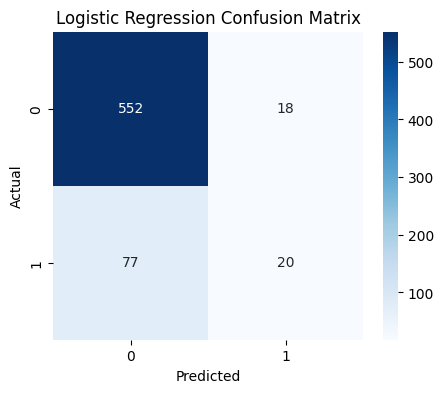

In [55]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

### Decision Tree

A Decision Tree is a non-linear machine learning algorithm that classifies observations by recursively splitting the feature space into decision regions. Unlike Logistic Regression, Decision Trees can naturally capture non-linear relationships and interactions between variables without requiring feature scaling.

Because Decision Trees are insensitive to the scale of the input features, the original training data are used for model fitting.

In [60]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [62]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [58]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1-score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

Accuracy : 0.8920539730134932
Precision: 0.6404494382022472
Recall   : 0.5876288659793815
F1-score : 0.6129032258064516
ROC-AUC  : 0.7657442575510944


In [63]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       570
           1       0.72      0.55      0.62        97

    accuracy                           0.90       667
   macro avg       0.82      0.75      0.78       667
weighted avg       0.90      0.90      0.90       667



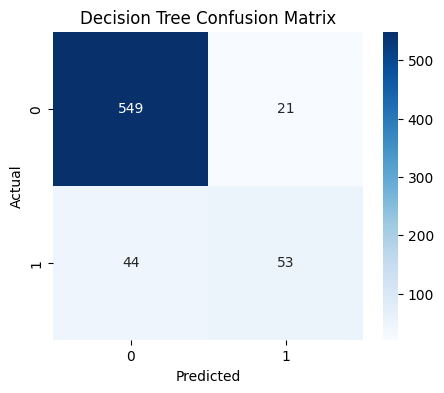

In [64]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

### Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to produce more robust and accurate predictions. Each tree is trained on a different sample of the data and considers a random subset of features when creating splits.

By aggregating the predictions of many trees, Random Forest reduces the risk of overfitting associated with a single Decision Tree and can capture complex non-linear relationships between customer characteristics and churn.

Because Random Forest is based on Decision Trees, feature scaling is not required.

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [66]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [67]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.9265367316341829
Precision: 0.8333333333333334
Recall   : 0.6185567010309279
F1-score : 0.7100591715976331
ROC-AUC  : 0.8582926388135285


In [68]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       570
           1       0.83      0.62      0.71        97

    accuracy                           0.93       667
   macro avg       0.89      0.80      0.83       667
weighted avg       0.92      0.93      0.92       667



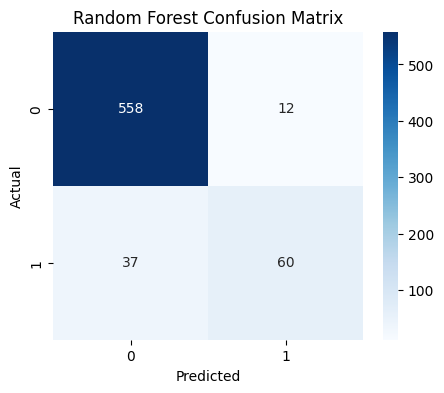

In [69]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

### K-Nearest Neighbors

K-Nearest Neighbors is a distance-based classification algorithm that predicts the class of a new observation based on the classes of its closest neighbors in the feature space.

Because the algorithm relies directly on distances between observations, feature scaling is essential to prevent variables with larger numerical ranges from dominating the prediction process.

In [70]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [71]:
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [72]:
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1-score :", f1_score(y_test, y_pred_knn))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_knn))

Accuracy : 0.8800599700149925
Precision: 0.6440677966101694
Recall   : 0.3917525773195876
F1-score : 0.48717948717948717
ROC-AUC  : 0.8112497739193344


In [73]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       570
           1       0.64      0.39      0.49        97

    accuracy                           0.88       667
   macro avg       0.77      0.68      0.71       667
weighted avg       0.87      0.88      0.87       667



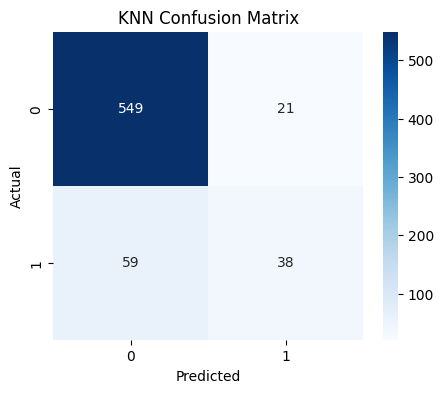

In [74]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

## Model Comparison

To identify the most effective approach for predicting customer churn, the performance of four classification algorithms was compared using multiple evaluation metrics.

Among the evaluated models, **Random Forest** achieved the best overall performance. It obtained the highest accuracy (92.7%), precision (83.3%), F1-score (0.71), and ROC-AUC (0.858), while also achieving the highest recall among the best-performing models. These results indicate that Random Forest provides the best balance between correctly identifying churned customers and minimizing false positive predictions.

Although the Decision Tree achieved a competitive recall, its overall predictive performance was lower than that of Random Forest. Logistic Regression produced the weakest results, particularly in terms of recall, indicating that many churned customers were not correctly identified. K-Nearest Neighbors performed better than Logistic Regression but remained inferior to Random Forest across most evaluation metrics.

Based on these results, **Random Forest** was selected as the final model for further interpretation and feature importance analysis.

## Feature Importance

Understanding which features contribute the most to a model's predictions is essential for translating machine learning results into actionable business insights.

Since Random Forest achieved the best predictive performance among the evaluated models, its feature importance scores are analyzed to identify the customer characteristics that have the greatest influence on churn prediction.

In [83]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

/tmp/ipykernel_1765/2338074718.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


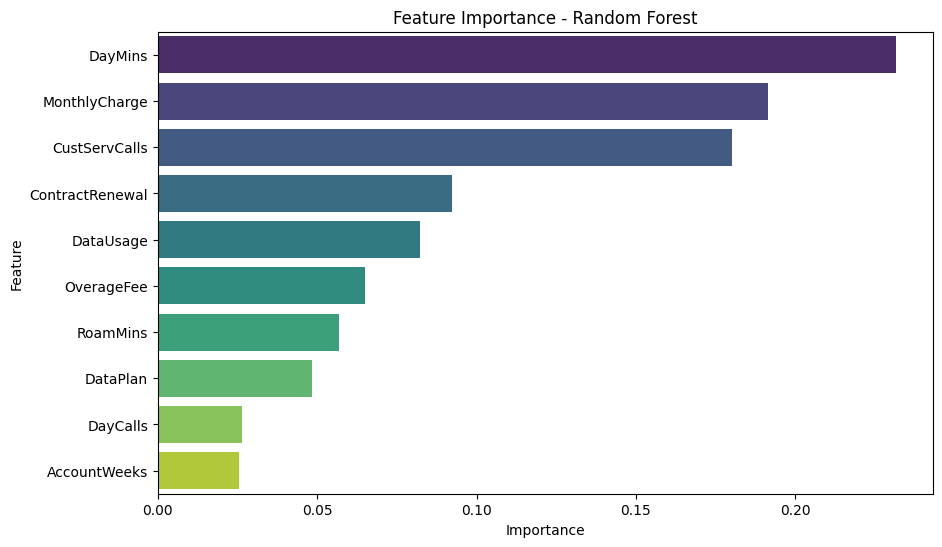

In [85]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [82]:
feature_importance.reset_index(drop=True)

,Feature,Importance
0,DayMins,0.231618
1,MonthlyCharge,0.191553
2,CustServCalls,0.180256
3,ContractRenewal,0.092306
4,DataUsage,0.082336
5,OverageFee,0.064883
6,RoamMins,0.056751
7,DataPlan,0.048419
8,DayCalls,0.026524
9,AccountWeeks,0.025355


### Conclusion

The Random Forest model identifies **Day Minutes**, **Monthly Charge**, and **Customer Service Calls** as the most influential features for predicting customer churn. These variables contribute the most to the model's decision-making process, highlighting the importance of customer usage patterns and service interactions.

**Contract Renewal** also ranks among the most relevant predictors, reinforcing the findings from the exploratory data analysis that customers who do not renew their contracts are substantially more likely to churn. Although its importance score is lower than that of the top three features, it remains a meaningful contributor to the model.

Features such as **Day Calls** and **Account Weeks** exhibit relatively low importance, suggesting that they provide limited additional predictive value when combined with the other variables.

Overall, the feature importance analysis is largely consistent with the exploratory analysis. Variables that showed stronger relationships with churn during the EDA also emerge as the most influential predictors in the Random Forest model, providing confidence that the observed patterns are meaningful and useful for predicting customer churn.

# 10. Business Recommendations

The analysis identified several customer characteristics that are strongly associated with churn, particularly **daytime usage**, **monthly charges**, **customer service interactions**, and **contract renewal status**. Based on these findings, the following business recommendations are proposed:

- **Prioritize customers without contract renewals.** Customers who have not renewed their contracts exhibit a higher likelihood of churning. Implementing renewal campaigns, personalized offers, or loyalty incentives may improve customer retention.

- **Monitor customers with high daytime usage and monthly charges.** These customers represent a higher churn risk and may benefit from customized pricing plans or usage-based promotions that better match their needs.

- **Improve customer service quality.** A high number of customer service calls is strongly associated with churn. Analyzing the reasons behind repeated support requests and resolving customer issues more efficiently could reduce dissatisfaction and increase retention.

- **Develop proactive retention strategies.** The Random Forest model can be integrated into a customer relationship management (CRM) system to identify high-risk customers before they leave, enabling targeted retention campaigns.

- **Continuously retrain the model.** Customer behavior changes over time, so periodically updating the model with new data will help maintain predictive performance and ensure that business decisions remain data-driven.